In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Download dataset from GitHub
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git --depth 1 -q
print("Dataset downloaded!")

import os
base_dir = '/content/PlantVillage-Dataset/raw/color'
classes = os.listdir(base_dir)
print(f"Total classes: {len(classes)}")
print("Classes:", classes[:5])

Dataset downloaded!
Total classes: 38
Classes: ['Tomato___Late_blight', 'Peach___Bacterial_spot', 'Tomato___Bacterial_spot', 'Tomato___Tomato_mosaic_virus', 'Apple___Cedar_apple_rust']


In [ ]:
# Train simple CNN model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generators
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    base_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Data ready!")
print(f"Training images: {train_gen.samples}")
print(f"Validation images: {val_gen.samples}")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Data ready!
Training images: 43456
Validation images: 10849


In [ ]:
# Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(38, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,282,918 (4.89 MB)

 Trainable params: 1,282,918 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model - only 3 epochs (fast!)
history = model.fit(
    train_gen,
    epochs=3,
    validation_data=val_gen,
    verbose=1
)

print("Training complete!")

Epoch 1/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 477s 349ms/step - accuracy: 0.5448 - loss: 1.6218 - val_accuracy: 0.7650 - val_loss: 0.7657
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 435s 320ms/step - accuracy: 0.7413 - loss: 0.8436 - val_accuracy: 0.8398 - val_loss: 0.5143
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 434s 319ms/step - accuracy: 0.7953 - loss: 0.6573 - val_accuracy: 0.8835 - val_loss: 0.3778
Training complete!


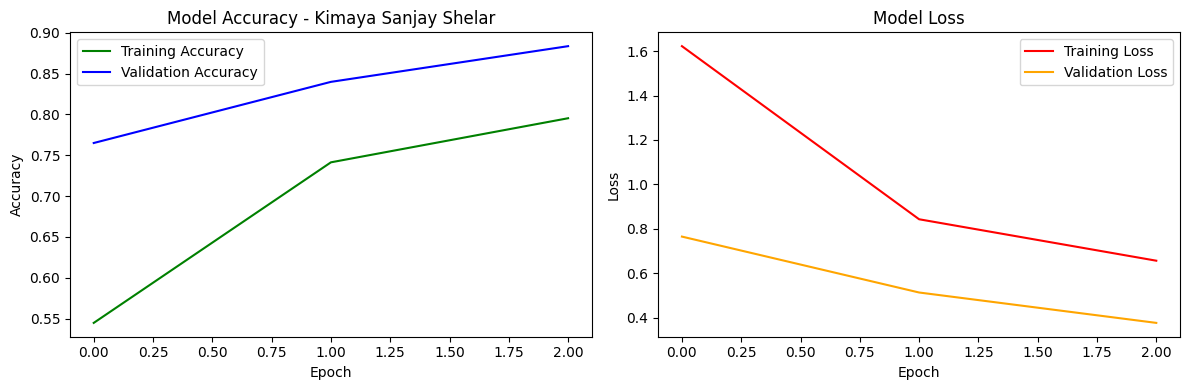

Graph saved!


In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy - Kimaya Sanjay Shelar')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('accuracy_graph.png')
plt.show()
print("Graph saved!")